In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE_DIR = Path("..").resolve().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"

plt.style.use("seaborn-v0_8-darkgrid")

In [2]:
bowling = pd.read_csv(PROCESSED_DIR / "bowling_metrics.csv")
playing_xi = pd.read_csv(PROCESSED_DIR / "final_playing_xi.csv")

bowling.head()

,bowler,runs_conceded,balls,wickets,overs,economy,Death_x,Middle_x,Powerplay_x,Death_y,Middle_y,Powerplay_y
0,A Ashish Reddy,388,262,18,43.666667,8.885496,9.742574,7.896774,20.000000,101,155,6
1,A Badoni,50,35,4,5.833333,8.571429,7.125000,10.333333,0.000000,16,18,1
2,A Chandila,245,234,11,39.000000,6.282051,6.000000,7.142857,5.791667,6,84,144
3,A Choudhary,137,101,5,16.833333,8.138614,9.250000,8.048780,7.500000,24,41,36
4,A Dananjaya,46,24,0,4.000000,11.500000,NaN,11.333333,12.000000,0,18,6


In [3]:
bowler_roles = [
    "Powerplay Bowler",
    "Middle Overs Bowler",
    "Death Bowler"
]

bowlers_in_xi = playing_xi[
    playing_xi["role"].isin(bowler_roles)
]["player"]

bowling_xi = bowling[bowling["bowler"].isin(bowlers_in_xi)]
bowling_xi

,bowler,runs_conceded,balls,wickets,overs,economy,Death_x,Middle_x,Powerplay_x,Death_y,Middle_y,Powerplay_y
72,B Kumar,5336,4222,198,703.666667,7.583136,9.186858,8.374408,6.438649,1461,422,2339
201,JJ Bumrah,3987,3359,186,559.833333,7.121762,8.074349,6.468966,6.498252,1345,870,1144
370,R Ashwin,5521,4710,184,785.000000,7.033121,7.926789,6.871544,6.972843,601,2857,1252


In [5]:
# Create economy columns if missing

bowling_xi["powerplay_economy"] = bowling_xi["Powerplay_y"] / (bowling_xi["Powerplay_x"] / 6)

bowling_xi["middle_overs_economy"] = bowling_xi["Middle_y"] / (bowling_xi["Middle_x"] / 6)

bowling_xi["death_overs_economy"] = bowling_xi["Death_y"] / (bowling_xi["Death_x"] / 6)

# Replace infinite values
bowling_xi = bowling_xi.replace([float("inf"), -float("inf")], 0)

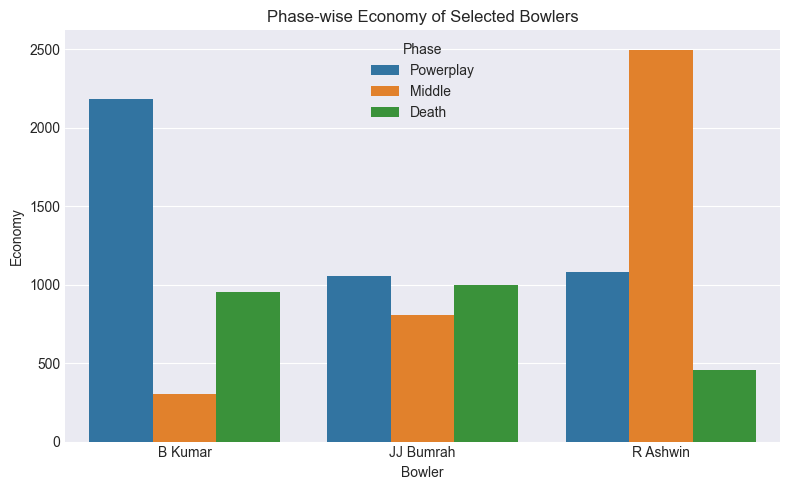

In [6]:
econ_cols = [
    "powerplay_economy",
    "middle_overs_economy",
    "death_overs_economy"
]

econ_melted = bowling_xi.melt(
    id_vars=["bowler"],
    value_vars=econ_cols,
    var_name="Phase",
    value_name="Economy"
)

econ_melted["Phase"] = econ_melted["Phase"].str.replace(
    "_economy", ""
).str.replace("_overs", "").str.title()

plt.figure(figsize=(8, 5))
sns.barplot(
    data=econ_melted,
    x="bowler",
    y="Economy",
    hue="Phase"
)

plt.title("Phase-wise Economy of Selected Bowlers")
plt.xlabel("Bowler")
plt.ylabel("Economy")
plt.tight_layout()
plt.show()

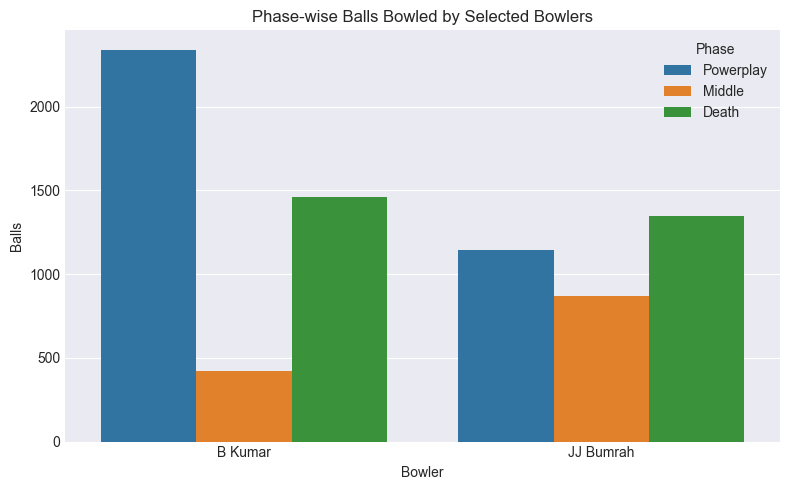

In [ ]:
ball_cols = [
    "powerplay_balls_bowled",
    "middle_overs_balls_bowled",
    "death_overs_balls_bowled"
]

balls_melted = bowling_xi.melt(
    id_vars=["bowler"],
    value_vars=ball_cols,
    var_name="Phase",
    value_name="Balls Bowled"
)

balls_melted["Phase"] = balls_melted["Phase"].str.replace(
    "_balls_bowled", ""
).str.replace("_overs", "").str.title()

plt.figure(figsize=(8, 5))
sns.barplot(
    data=balls_melted,
    x="bowler",
    y="Balls Bowled",
    hue="Phase"
)

plt.title("Phase-wise Balls Bowled by Selected Bowlers")
plt.xlabel("Bowler")
plt.ylabel("Balls")
plt.tight_layout()
plt.show()